# 02. Revenue Forecasting and Channel Investment Recommendation

Candidate Number: VSXB6

This notebook is the next step after data cleaning and EDA. It builds a predictive machine learning workflow to answer the business question:

**If I have additional marketing budget, which channel(s) should receive that incremental spend, and what percentage should be allocated to each channel to maximise future revenue uplift?**

Modeling approach:
- use historical data from a single comparable time series
- forecast revenue using time-aware features and channel spend
- compare models with chronological validation
- simulate an incremental budget increase in each channel, estimate uplift per extra spend, and convert efficiencies into percentage allocation recommendations

Important note:
The raw dataset contains multiple currencies, so revenue cannot be safely aggregated across all brands and territories. To keep the analysis valid, this notebook automatically selects one strong candidate time series and models revenue within that series only.

Scope clarification:
- This notebook supports **incremental budget reallocation** decisions, including channel priority and percentage split.
- It does **not** solve a full constrained optimisation of the entire next-year budget from scratch.

## End-to-end ML workflow used in this notebook

1. **Problem framing**: Define revenue target and **incremental budget allocation** decision question.
2. **Data loading and filtering**: Use cleaned data and choose a defensible single series.
3. **Preparation and feature engineering**: Build time, lag, rolling, and spend-share predictors.
4. **Modelling**: Train baseline and regularised models with chronological splits.
5. **Evaluation**: Compare metrics on validation/test and inspect prediction errors.
6. **Decision support**: Simulate +10% channel budget scenarios, rank channels by uplift efficiency, and produce percentage allocation across channels.
7. **Final narrative**: Summarise channel priority, percentage split recommendation, rationale, and caveats.


## 1. Setup

In [1]:
# Explain: Import a required package.
import sys
# Explain: Import specific objects from a package.
from pathlib import Path

# Explain: Import a required package.
import numpy as np
# Explain: Import a required package.
import pandas as pd
# Explain: Import a required package.
import seaborn as sns
# Explain: Import a required package.
import matplotlib.pyplot as plt

# Explain: Import specific objects from a package.
from sklearn.linear_model import ElasticNet, Ridge
# Explain: Import specific objects from a package.
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

# Explain: Execute this step in the workflow.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
# Explain: Apply a condition to control execution.
if str(PROJECT_ROOT) not in sys.path:
    # Explain: Execute this step in the workflow.
    sys.path.insert(0, str(PROJECT_ROOT))

# Explain: Import specific objects from a package.
from src.config import DATE_COLUMN, RAW_DATA_PATH

# Explain: Create or format a visualization.
sns.set_theme(style="whitegrid")
# Explain: Run a pandas/numpy data operation.
pd.set_option("display.max_columns", 200)
# Explain: Run a pandas/numpy data operation.
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Load the cleaned dataset if available

In [2]:
# Explain: Create or update a variable used later.
clean_path = PROJECT_ROOT / "dataset" / "conjura_mmm_data_cleaned.parquet"

# Explain: Apply a condition to control execution.
if clean_path.exists():
    # Explain: Create or update a variable used later.
    df = pd.read_parquet(clean_path)
# Explain: Run the fallback branch when prior conditions fail.
else:
    # Explain: Create or update a variable used later.
    df = pd.read_csv(RAW_DATA_PATH)

# Explain: Create or update a variable used later.
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
# Explain: Create or update a variable used later.
df = df.sort_values(["MMM_TIMESERIES_ID", DATE_COLUMN]).reset_index(drop=True)
# Explain: Print output for quick inspection.
print(df.shape)
# Explain: Execute this step in the workflow.
df.head()

(132759, 59)


,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,GOOGLE_PAID_SEARCH_CLICKS,GOOGLE_SHOPPING_CLICKS,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_DISPLAY_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS,year,month,quarter,day_of_week,is_weekend,total_paid_spend,total_paid_clicks,total_paid_impressions,total_non_paid_clicks
0,000735021aa3b94ec319dbe83d137874,8d85172419d0499b1e601c1a4e9b0a45,Home & Garden,Nursery & Playroom,"Google, Meta, Tiktok",US,All Territories,2022-05-30,USD,3,3,499.0000,0.0000,4,4,797.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,20.0000,0.0000,35.0000,3.0000,10.0000,19.0000,2022,5,2,0,0,0.0000,87.0000,0.0000,87.0000
1,000735021aa3b94ec319dbe83d137874,8d85172419d0499b1e601c1a4e9b0a45,Home & Garden,Nursery & Playroom,"Google, Meta, Tiktok",US,All Territories,2022-05-31,USD,3,3,358.0000,0.0000,3,3,358.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,39.0000,0.0000,44.0000,1.0000,7.0000,15.0000,2022,5,2,1,0,0.0000,106.0000,0.0000,106.0000
2,000735021aa3b94ec319dbe83d137874,8d85172419d0499b1e601c1a4e9b0a45,Home & Garden,Nursery & Playroom,"Google, Meta, Tiktok",US,All Territories,2022-06-01,USD,2,2,299.0000,0.0000,2,2,299.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,29.0000,0.0000,54.0000,0.0000,4.0000,14.0000,2022,6,2,2,0,0.0000,101.0000,0.0000,101.0000
3,000735021aa3b94ec319dbe83d137874,8d85172419d0499b1e601c1a4e9b0a45,Home & Garden,Nursery & Playroom,"Google, Meta, Tiktok",US,All Territories,2022-06-02,USD,3,4,760.0000,0.0000,4,5,809.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,33.0000,0.0000,54.0000,2.0000,4.0000,12.0000,2022,6,2,3,0,0.0000,105.0000,0.0000,105.0000
4,000735021aa3b94ec319dbe83d137874,8d85172419d0499b1e601c1a4e9b0a45,Home & Garden,Nursery & Playroom,"Google, Meta, Tiktok",US,All Territories,2022-06-03,USD,1,1,200.0000,25.0000,1,1,200.0000,25.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,28.0000,0.0000,35.0000,3.0000,8.0000,18.0000,2022,6,2,4,0,0.0000,92.0000,0.0000,92.0000


### Table interpretation

- The preview confirms the dataset loaded successfully and is sorted by date for time-series use.
- Early rows look consistent with expected fields (date, targets, and channel variables).
- This validates that the pipeline starts from correctly structured input data.


## 3. Choose a revenue target and a defensible modelling unit

In [3]:
# Explain: Create or update a variable used later.
target_col = "ALL_PURCHASES_ORIGINAL_PRICE"
# Explain: Create or update a variable used later.
spend_cols = [col for col in df.columns if col.endswith("_SPEND")]

# Explain: Create or update a variable used later.
series_summary = (
    # Explain: Execute this step in the workflow.
    df.groupby("MMM_TIMESERIES_ID")
    # Explain: Execute this step in the workflow.
    .agg(
        # Explain: Create or update a variable used later.
        currency_code=("CURRENCY_CODE", "first"),
        # Explain: Create or update a variable used later.
        territory_name=("TERRITORY_NAME", "first"),
        # Explain: Create or update a variable used later.
        organisation_id=("ORGANISATION_ID", "first"),
        # Explain: Create or update a variable used later.
        n_obs=(DATE_COLUMN, "count"),
        # Explain: Create or update a variable used later.
        date_min=(DATE_COLUMN, "min"),
        # Explain: Create or update a variable used later.
        date_max=(DATE_COLUMN, "max"),
        # Explain: Create or update a variable used later.
        total_revenue=(target_col, "sum"),
    # Explain: Execute this step in the workflow.
    )
    # Explain: Execute this step in the workflow.
    .reset_index()
# Explain: Execute this step in the workflow.
)

# Explain: Create or update a variable used later.
channel_activity = (
    # Explain: Execute this step in the workflow.
    df.groupby("MMM_TIMESERIES_ID")[spend_cols]
    # Explain: Execute this step in the workflow.
    .sum()
    # Explain: Execute this step in the workflow.
    .gt(0)
    # Explain: Create or update a variable used later.
    .sum(axis=1)
    # Explain: Execute this step in the workflow.
    .rename("active_paid_channels")
    # Explain: Execute this step in the workflow.
    .reset_index()
# Explain: Execute this step in the workflow.
)

# Explain: Create or update a variable used later.
series_summary = series_summary.merge(channel_activity, on="MMM_TIMESERIES_ID", how="left")
# Explain: Execute this step in the workflow.
candidate_series = series_summary.query("n_obs >= 500 and active_paid_channels >= 3").copy()
# Explain: Create or update a variable used later.
candidate_series = candidate_series.sort_values(["active_paid_channels", "n_obs", "total_revenue"], ascending=[False, False, False])
# Explain: Execute this step in the workflow.
candidate_series.head(10)

,MMM_TIMESERIES_ID,currency_code,territory_name,organisation_id,n_obs,date_min,date_max,total_revenue,active_paid_channels
140,f7493de0a760f84888105af70245bed3,USD,All Territories,4a762f02ca755b22d37393e8dbeab1a6,1030,2021-07-26,2024-05-20,"9,382,903.2652",9
2,0349b43cddf6e720b5d582afc8cd7fd6,USD,US,4a762f02ca755b22d37393e8dbeab1a6,1029,2021-07-26,2024-05-19,"7,301,102.8700",9
88,ac9965a4cc73306fa9e4fcc0ac581eb5,USD,All Territories,7569a6a9c156a0f9398fa6cfd51df5bb,821,2021-10-15,2024-01-13,"30,368,974.9226",9
42,513211a5ba7d7c20145586b16abfda54,USD,US,7569a6a9c156a0f9398fa6cfd51df5bb,821,2021-10-15,2024-01-13,"24,782,886.6400",9
97,bff180584891aa08503731ed4ceaf477,USD,All Territories,8d28b004d2d89ed65b035a9430c3eb8a,622,2022-09-06,2024-05-19,"4,717,945.5178",9
43,51c8843bddcc604ebb3fe8d638ee5a1d,GBP,All Territories,ba773ebd7ec0a08f1d042187d086ccb4,1610,2020-01-06,2024-06-02,"248,678,660.6694",8
68,7b931b65f91d4ae452ad55dd221c1072,USD,All Territories,09113a73f8618b48b3cf53b24cd78d2f,1450,2020-06-14,2024-06-02,"17,636,969.9635",8
59,6be017619bfb9354aaa747f6c2dca447,GBP,All Territories,784d6aa3cda59f59f2400332b2420a49,1415,2020-04-21,2024-03-05,"67,659,815.4170",8
118,d074408382106c56fa366d6a8351bbfa,USD,US,784d6aa3cda59f59f2400332b2420a49,1415,2020-04-21,2024-03-05,"28,102,771.6300",8
57,6b89cf94d2e23372be3846ed656b5e47,GBP,UK,784d6aa3cda59f59f2400332b2420a49,1389,2020-04-21,2024-02-08,"43,598,658.8400",8


### Table interpretation

- Candidate series are ranked by data depth and channel activity.
- The top rows indicate which series are most suitable for forecasting and channel analysis.
- This result supports choosing one robust series instead of mixing incompatible units.


In [4]:
# Explain: Create or update a variable used later.
selected_series_id = candidate_series.iloc[0]["MMM_TIMESERIES_ID"]
# Explain: Create or update a variable used later.
selected_meta = candidate_series.iloc[0]

# Explain: Execute this step in the workflow.
selected_meta

MMM_TIMESERIES_ID       f7493de0a760f84888105af70245bed3
currency_code                                        USD
territory_name                           All Territories
organisation_id         4a762f02ca755b22d37393e8dbeab1a6
n_obs                                               1030
date_min                             2021-07-26 00:00:00
date_max                             2024-05-20 00:00:00
total_revenue                             9,382,903.2652
active_paid_channels                                   9
Name: 140, dtype: object

The notebook uses the strongest candidate time series so revenue stays in one currency and the history is long enough for forecasting.

## 4. Build the modelling dataset for the selected series

In [5]:
# Explain: Execute this step in the workflow.
series_df = df[df["MMM_TIMESERIES_ID"] == selected_series_id].copy()
# Explain: Create or update a variable used later.
series_df = series_df.sort_values(DATE_COLUMN).reset_index(drop=True)
# Explain: Create or update a variable used later.
series_df[spend_cols] = series_df[spend_cols].fillna(0)

# Explain: Create or update a variable used later.
keep_cols = [
    # Explain: Execute this step in the workflow.
    DATE_COLUMN,
    # Explain: Execute this step in the workflow.
    target_col,
    # Explain: Execute this step in the workflow.
    "CURRENCY_CODE",
    # Explain: Execute this step in the workflow.
    "TERRITORY_NAME",
    # Explain: Execute this step in the workflow.
    "ORGANISATION_VERTICAL",
# Explain: Execute this step in the workflow.
] + spend_cols

# Explain: Create or update a variable used later.
series_df = series_df[keep_cols].copy()
# Explain: Execute this step in the workflow.
series_df.head()

,DATE_DAY,ALL_PURCHASES_ORIGINAL_PRICE,CURRENCY_CODE,TERRITORY_NAME,ORGANISATION_VERTICAL,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND
0,2021-07-26,319.0000,USD,All Territories,Apparel,32.8700,45.5100,0.0000,0.0000,0.0000,39.8400,0.0000,0.0000,0.0000
1,2021-07-27,665.0000,USD,All Territories,Apparel,21.8400,58.0000,0.0000,0.0000,0.0000,32.9600,0.0000,0.0000,0.0000
2,2021-07-28,"1,142.0000",USD,All Territories,Apparel,16.6700,106.9000,0.0000,0.0000,0.0000,56.3600,0.0000,0.0000,0.0000
3,2021-07-29,"1,184.9935",USD,All Territories,Apparel,12.9500,76.6700,0.0000,0.0000,0.0000,101.7000,0.0000,0.0000,0.0000
4,2021-07-30,"1,035.9998",USD,All Territories,Apparel,23.0200,102.1300,0.0000,0.0000,0.0000,151.3000,0.0000,0.0000,0.0000


### Table interpretation

- The selected-series preview shows the exact modelling unit used downstream.
- Spend and target fields appear aligned at daily granularity.
- This confirms the model input is consistent for a single currency/time-series context.


## 5. Feature engineering for time-series forecasting

In [6]:
# Explain: Create or update a variable used later.
feature_df = series_df.copy()

# Explain: Create or update a variable used later.
feature_df["revenue"] = feature_df[target_col]
# Explain: Create or update a variable used later.
feature_df["log_revenue"] = np.log1p(feature_df["revenue"])
# Explain: Create or update a variable used later.
feature_df["total_paid_spend"] = feature_df[spend_cols].sum(axis=1)
# Explain: Create or update a variable used later.
feature_df["day_of_week"] = feature_df[DATE_COLUMN].dt.dayofweek
# Explain: Create or update a variable used later.
feature_df["month"] = feature_df[DATE_COLUMN].dt.month
# Explain: Create or update a variable used later.
feature_df["day_of_year"] = feature_df[DATE_COLUMN].dt.dayofyear
# Explain: Create or update a variable used later.
feature_df["sin_day_of_year"] = np.sin(2 * np.pi * feature_df["day_of_year"] / 365.25)
# Explain: Create or update a variable used later.
feature_df["cos_day_of_year"] = np.cos(2 * np.pi * feature_df["day_of_year"] / 365.25)
# Explain: Create or update a variable used later.
feature_df["trend_index"] = np.arange(len(feature_df))

# Explain: Start a loop over a sequence.
for lag in [1, 7, 14, 28]:
    # Explain: Create or update a variable used later.
    feature_df[f"revenue_lag_{lag}"] = feature_df["revenue"].shift(lag)

# Explain: Start a loop over a sequence.
for window in [7, 28]:
    # Explain: Create or update a variable used later.
    feature_df[f"revenue_roll_mean_{window}"] = feature_df["revenue"].shift(1).rolling(window).mean()

# Explain: Start a loop over a sequence.
for col in spend_cols:
    # Explain: Create or update a variable used later.
    feature_df[f"log_{col}"] = np.log1p(feature_df[col])
    # Explain: Create or update a variable used later.
    feature_df[f"{col}_lag_1"] = feature_df[col].shift(1)
    # Explain: Create or update a variable used later.
    feature_df[f"{col}_lag_7"] = feature_df[col].shift(7)
    # Explain: Create or update a variable used later.
    feature_df[f"{col}_roll_mean_7"] = feature_df[col].shift(1).rolling(7).mean()
    # Explain: Create or update a variable used later.
    feature_df[f"{col}_share"] = feature_df[col] / feature_df["total_paid_spend"].replace(0, np.nan)

# Explain: Create or update a variable used later.
feature_df["total_paid_spend_lag_1"] = feature_df["total_paid_spend"].shift(1)
# Explain: Create or update a variable used later.
feature_df["total_paid_spend_roll_mean_7"] = feature_df["total_paid_spend"].shift(1).rolling(7).mean()
# Explain: Create or update a variable used later.
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
# Explain: Create or update a variable used later.
feature_df = feature_df.dropna().reset_index(drop=True)
# Explain: Execute this step in the workflow.
feature_df.head()

,DATE_DAY,ALL_PURCHASES_ORIGINAL_PRICE,CURRENCY_CODE,TERRITORY_NAME,ORGANISATION_VERTICAL,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,revenue,log_revenue,total_paid_spend,day_of_week,month,day_of_year,sin_day_of_year,cos_day_of_year,trend_index,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_28,revenue_roll_mean_7,revenue_roll_mean_28,log_GOOGLE_PAID_SEARCH_SPEND,GOOGLE_PAID_SEARCH_SPEND_lag_1,GOOGLE_PAID_SEARCH_SPEND_lag_7,GOOGLE_PAID_SEARCH_SPEND_roll_mean_7,GOOGLE_PAID_SEARCH_SPEND_share,log_GOOGLE_SHOPPING_SPEND,GOOGLE_SHOPPING_SPEND_lag_1,GOOGLE_SHOPPING_SPEND_lag_7,GOOGLE_SHOPPING_SPEND_roll_mean_7,GOOGLE_SHOPPING_SPEND_share,log_GOOGLE_PMAX_SPEND,GOOGLE_PMAX_SPEND_lag_1,GOOGLE_PMAX_SPEND_lag_7,GOOGLE_PMAX_SPEND_roll_mean_7,GOOGLE_PMAX_SPEND_share,log_GOOGLE_DISPLAY_SPEND,GOOGLE_DISPLAY_SPEND_lag_1,GOOGLE_DISPLAY_SPEND_lag_7,GOOGLE_DISPLAY_SPEND_roll_mean_7,GOOGLE_DISPLAY_SPEND_share,log_GOOGLE_VIDEO_SPEND,GOOGLE_VIDEO_SPEND_lag_1,GOOGLE_VIDEO_SPEND_lag_7,GOOGLE_VIDEO_SPEND_roll_mean_7,GOOGLE_VIDEO_SPEND_share,log_META_FACEBOOK_SPEND,META_FACEBOOK_SPEND_lag_1,META_FACEBOOK_SPEND_lag_7,META_FACEBOOK_SPEND_roll_mean_7,META_FACEBOOK_SPEND_share,log_META_INSTAGRAM_SPEND,META_INSTAGRAM_SPEND_lag_1,META_INSTAGRAM_SPEND_lag_7,META_INSTAGRAM_SPEND_roll_mean_7,META_INSTAGRAM_SPEND_share,log_META_OTHER_SPEND,META_OTHER_SPEND_lag_1,META_OTHER_SPEND_lag_7,META_OTHER_SPEND_roll_mean_7,META_OTHER_SPEND_share,log_TIKTOK_SPEND,TIKTOK_SPEND_lag_1,TIKTOK_SPEND_lag_7,TIKTOK_SPEND_roll_mean_7,TIKTOK_SPEND_share,total_paid_spend_lag_1,total_paid_spend_roll_mean_7
0,2021-08-23,"2,547.0000",USD,All Territories,Apparel,24.0100,267.2100,0.0000,0.0000,0.0000,161.4100,0.0000,0.0000,0.0000,"2,547.0000",7.8431,452.6300,0,8,235,-0.7839,-0.6208,28,"3,711.0000","2,473.0000","1,905.0000",319.0000,"2,454.4290","2,056.5355",3.2193,39.2900,46.9200,41.6014,0.0530,5.5918,332.0300,309.3700,306.5471,0.5903,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0901,209.9800,225.6500,212.6743,0.3566,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,581.3000,560.8229
1,2021-08-24,"2,872.0000",USD,All Territories,Apparel,29.8200,364.8500,0.0000,0.0000,0.0000,156.8700,0.0000,0.0000,0.0000,"2,872.0000",7.9631,551.5400,1,8,236,-0.7945,-0.6073,29,"2,547.0000","1,731.0000","2,904.0000",665.0000,"2,465.0005","2,136.1069",3.4282,24.0100,46.1800,38.3286,0.0541,5.9022,267.2100,306.4200,300.5243,0.6615,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0618,161.4100,225.8100,203.4971,0.2844,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,452.6300,542.3500
2,2021-08-25,"2,746.0000",USD,All Territories,Apparel,52.4700,458.3900,0.0000,0.0000,0.0000,155.4900,0.0000,0.0000,0.0000,"2,746.0000",7.9183,666.3500,2,8,237,-0.8048,-0.5935,30,"2,872.0000","2,542.0000","3,172.0000","1,142.0000","2,628.0005","2,214.9284",3.9791,29.8200,40.8500,35.9914,0.0787,6.1299,364.8500,298.0700,308.8714,0.6879,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0530,156.8700,205.5200,193.6486,0.2333,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,551.5400,538.5114
3,2021-08-26,"2,575.0000",USD,All Territories,Apparel,23.2400,406.4100,0.0000,0.0000,0.0000,162.9600,0.0000,0.0000,0.0000,"2,575.0000",7.8540,592.6100,3,8,238,-0.8149,-0.5796,31,"2,746.0000","2,450.0000","2,493.0000","1,184.9935","2,657.1433","2,272.2141",3.1880,52.4700,36.0800,37.6514,0.0392,6.0098,458.3900,273.2500,331.7743,0.6858,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0996,155.4900,205.0600,186.5014,0.2750,0

### Table interpretation

- The engineered feature preview confirms lag, rolling, seasonal, and spend-share fields were created.
- Rows with incomplete lag history are removed, leaving model-ready records.
- This table verifies that temporal predictors are available before training.


## 6. Create chronological train, validation, and test splits

In [7]:
# Explain: Create or update a variable used later.
feature_cols = [
    # Explain: Execute this step in the workflow.
    col for col in feature_df.columns
    # Explain: Apply a condition to control execution.
    if col not in {
        # Explain: Execute this step in the workflow.
        DATE_COLUMN,
        # Explain: Execute this step in the workflow.
        target_col,
        # Explain: Execute this step in the workflow.
        "revenue",
        # Explain: Execute this step in the workflow.
        "log_revenue",
        # Explain: Execute this step in the workflow.
        "CURRENCY_CODE",
        # Explain: Execute this step in the workflow.
        "TERRITORY_NAME",
        # Explain: Execute this step in the workflow.
        "ORGANISATION_VERTICAL",
    # Explain: Execute this step in the workflow.
    }
# Explain: Execute this step in the workflow.
]

# Explain: Create or update a variable used later.
n_rows = len(feature_df)
# Explain: Create or update a variable used later.
train_end = int(n_rows * 0.70)
# Explain: Create or update a variable used later.
valid_end = int(n_rows * 0.85)

# Explain: Create or update a variable used later.
train_df = feature_df.iloc[:train_end].copy()
# Explain: Create or update a variable used later.
valid_df = feature_df.iloc[train_end:valid_end].copy()
# Explain: Create or update a variable used later.
test_df = feature_df.iloc[valid_end:].copy()

# Explain: Create or update a variable used later.
X_train = train_df[feature_cols]
# Explain: Create or update a variable used later.
y_train = train_df["log_revenue"]
# Explain: Create or update a variable used later.
X_valid = valid_df[feature_cols]
# Explain: Create or update a variable used later.
y_valid = valid_df["log_revenue"]
# Explain: Create or update a variable used later.
X_test = test_df[feature_cols]
# Explain: Create or update a variable used later.
y_test = test_df["log_revenue"]

# Explain: Run a pandas/numpy data operation.
pd.DataFrame(
    # Explain: Execute this step in the workflow.
    {
        # Explain: Execute this step in the workflow.
        "split": ["train", "validation", "test"],
        # Explain: Execute this step in the workflow.
        "rows": [len(train_df), len(valid_df), len(test_df)],
        # Explain: Execute this step in the workflow.
        "date_min": [train_df[DATE_COLUMN].min(), valid_df[DATE_COLUMN].min(), test_df[DATE_COLUMN].min()],
        # Explain: Execute this step in the workflow.
        "date_max": [train_df[DATE_COLUMN].max(), valid_df[DATE_COLUMN].max(), test_df[DATE_COLUMN].max()],
    # Explain: Execute this step in the workflow.
    }
# Explain: Execute this step in the workflow.
)

,split,rows,date_min,date_max
0,train,701,2021-08-23,2023-07-24
1,validation,150,2023-07-25,2023-12-21
2,test,151,2023-12-22,2024-05-20


### Table interpretation

- The split table confirms chronological train/validation/test boundaries.
- Date ranges do not overlap, which helps prevent time leakage.
- Row counts indicate each split has enough observations for evaluation.


## 7. Define a baseline and candidate models

Model set used in this notebook:
- seasonal naive baseline
- Ridge regression
- ElasticNet regression
- Bootstrapped Ridge regression

The bootstrapped Ridge model repeatedly resamples the training data, fits Ridge on each bootstrap sample, and averages predictions. This gives a more stable linear benchmark and can later be extended to estimate uncertainty bands.

### Evaluation metric used for model selection
- **Primary selection metric:** `RMSE` on the validation split (lower is better).
- **Supporting metrics:** `MAE`, `MAPE`, and `R2_log_scale`.
- **Reason:** RMSE penalises large forecast errors more strongly, which is useful for revenue-risk control.

In [8]:
# Explain: Define a reusable function.
def evaluate_predictions(y_true_log, y_pred_log):
    # Explain: Create or update a variable used later.
    y_true = np.expm1(y_true_log)
    # Explain: Create or update a variable used later.
    y_pred = np.expm1(y_pred_log)
    # Explain: Return a value from the function.
    return {
        # Explain: Execute this step in the workflow.
        "MAE": mean_absolute_error(y_true, y_pred),
        # Explain: Execute this step in the workflow.
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        # Explain: Create or update a variable used later.
        "MAPE": mean_absolute_percentage_error(y_true.clip(lower=1), y_pred.clip(min=1)),
        # Explain: Execute this step in the workflow.
        "R2_log_scale": r2_score(y_true_log, y_pred_log),
    # Explain: Execute this step in the workflow.
    }

# Explain: Define a reusable function.
def seasonal_naive_predict(valid_or_test_df):
    # Explain: Return a value from the function.
    return np.log1p(valid_or_test_df["revenue_lag_7"].values)

# Explain: Define a reusable function.
def fit_bootstrapped_ridge(X_train, y_train, n_bootstrap=50, alpha=1.0, random_state=42):
    # Explain: Create or update a variable used later.
    rng = np.random.default_rng(random_state)
    # Explain: Create or update a variable used later.
    boot_models = []
    # Explain: Create or update a variable used later.
    n_samples = len(X_train)
    # Explain: Create or update a variable used later.
    X_train_np = X_train.to_numpy()
    # Explain: Create or update a variable used later.
    y_train_np = y_train.to_numpy()
    # Explain: Start a loop over a sequence.
    for _ in range(n_bootstrap):
        # Explain: Create or update a variable used later.
        sample_idx = rng.choice(n_samples, size=n_samples, replace=True)
        # Explain: Create or update a variable used later.
        model = Ridge(alpha=alpha)
        # Explain: Execute this step in the workflow.
        model.fit(X_train_np[sample_idx], y_train_np[sample_idx])
        # Explain: Execute this step in the workflow.
        boot_models.append(model)
    # Explain: Return a value from the function.
    return boot_models

# Explain: Define a reusable function.
def predict_bootstrapped_ridge(boot_models, X):
    # Explain: Create or update a variable used later.
    X_np = X.to_numpy()
    # Explain: Create or update a variable used later.
    preds = np.column_stack([model.predict(X_np) for model in boot_models])
    # Explain: Return a value from the function.
    return preds.mean(axis=1)

# Explain: Create or update a variable used later.
models = {
    # Explain: Create or update a variable used later.
    "ridge": Ridge(alpha=1.0),
    # Explain: Create or update a variable used later.
    "elastic_net": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=20000, random_state=42),
# Explain: Execute this step in the workflow.
}


In [9]:
# Explain: Create or update a variable used later.
validation_results = []

# Explain: Create or update a variable used later.
naive_pred_valid = seasonal_naive_predict(valid_df)
# Explain: Create or update a variable used later.
naive_metrics = evaluate_predictions(y_valid, naive_pred_valid)
# Explain: Execute this step in the workflow.
validation_results.append({"model": "seasonal_naive_lag_7", "is_ml_model": False, **naive_metrics})

# Explain: Create or update a variable used later.
fitted_models = {}
# Explain: Start a loop over a sequence.
for model_name, model in models.items():
    # Explain: Execute this step in the workflow.
    model.fit(X_train, y_train)
    # Explain: Create or update a variable used later.
    valid_pred = model.predict(X_valid)
    # Explain: Create or update a variable used later.
    metrics = evaluate_predictions(y_valid, valid_pred)
    # Explain: Execute this step in the workflow.
    validation_results.append({"model": model_name, "is_ml_model": True, **metrics})
    # Explain: Create or update a variable used later.
    fitted_models[model_name] = model

# Explain: Create or update a variable used later.
boot_ridge_models = fit_bootstrapped_ridge(X_train, y_train, n_bootstrap=50, alpha=1.0, random_state=42)
# Explain: Create or update a variable used later.
boot_ridge_valid_pred = predict_bootstrapped_ridge(boot_ridge_models, X_valid)
# Explain: Create or update a variable used later.
boot_ridge_metrics = evaluate_predictions(y_valid, boot_ridge_valid_pred)
# Explain: Execute this step in the workflow.
validation_results.append({"model": "bootstrapped_ridge", "is_ml_model": True, **boot_ridge_metrics})
# Explain: Create or update a variable used later.
fitted_models["bootstrapped_ridge"] = boot_ridge_models

# Explain: Create or update a variable used later.
validation_results_df = pd.DataFrame(validation_results).sort_values("RMSE")
# Explain: Execute this step in the workflow.
validation_results_df

,model,is_ml_model,MAE,RMSE,MAPE,R2_log_scale
3,bootstrapped_ridge,True,"2,051.7917","2,912.0379",0.1622,0.8059
1,ridge,True,"2,067.5937","2,934.6020",0.1620,0.8033
0,seasonal_naive_lag_7,False,"2,470.8109","3,435.3096",0.2241,0.6963
2,elastic_net,True,"3,885.6324","4,436.0783",0.4149,0.3776


### Table interpretation

- This table compares validation performance across baseline and ML models.
- The best model should be selected by lower error metrics (especially RMSE/MAE).
- Differences here directly determine which model is used for recommendation simulation.


## 8. Fit the best model on train + validation and evaluate on test

In [10]:
# Explain: Create or update a variable used later.
best_model_name = validation_results_df.iloc[0]["model"]
# Explain: Execute this step in the workflow.
best_ml_model_name = validation_results_df.query("is_ml_model == True").sort_values("RMSE").iloc[0]["model"]

# Explain: Create or update a variable used later.
X_train_valid = pd.concat([X_train, X_valid], axis=0)
# Explain: Create or update a variable used later.
y_train_valid = pd.concat([y_train, y_valid], axis=0)

# Explain: Apply a condition to control execution.
if best_model_name == "seasonal_naive_lag_7":
    # Explain: Create or update a variable used later.
    test_pred_log = seasonal_naive_predict(test_df)
    # Explain: Create or update a variable used later.
    best_model = None
# Explain: Add an alternative condition branch.
elif best_model_name == "bootstrapped_ridge":
    # Explain: Create or update a variable used later.
    best_model = fit_bootstrapped_ridge(X_train_valid, y_train_valid, n_bootstrap=50, alpha=1.0, random_state=42)
    # Explain: Create or update a variable used later.
    test_pred_log = predict_bootstrapped_ridge(best_model, X_test)
# Explain: Run the fallback branch when prior conditions fail.
else:
    # Explain: Create or update a variable used later.
    best_model = models[best_model_name]
    # Explain: Execute this step in the workflow.
    best_model.fit(X_train_valid, y_train_valid)
    # Explain: Create or update a variable used later.
    test_pred_log = best_model.predict(X_test)

# Explain: Create or update a variable used later.
test_metrics = pd.Series(evaluate_predictions(y_test, test_pred_log), name="test_metrics")
# Explain: Execute this step in the workflow.
test_metrics

MAE            4,647.4800
RMSE           6,366.9656
MAPE               0.4282
R2_log_scale      -0.3832
Name: test_metrics, dtype: float64

In [11]:
# Explain: Create or update a variable used later.
test_predictions = test_df[[DATE_COLUMN, "revenue"]].copy()
# Explain: Create or update a variable used later.
test_predictions["predicted_revenue"] = np.expm1(test_pred_log)
# Explain: Execute this step in the workflow.
test_predictions.head()

,DATE_DAY,revenue,predicted_revenue
851,2023-12-22,"3,438.3777","4,245.9543"
852,2023-12-23,"4,089.7929","4,107.5773"
853,2023-12-24,"2,467.7793","4,078.6502"
854,2023-12-25,"2,493.5997","3,888.4512"
855,2023-12-26,"4,118.9155","4,080.1436"


### Table interpretation

- The first test rows show predicted revenue alongside actual revenue values.
- Small gaps suggest closer fit, while large gaps indicate local forecast error.
- This provides a concrete check before moving to budget scenarios.


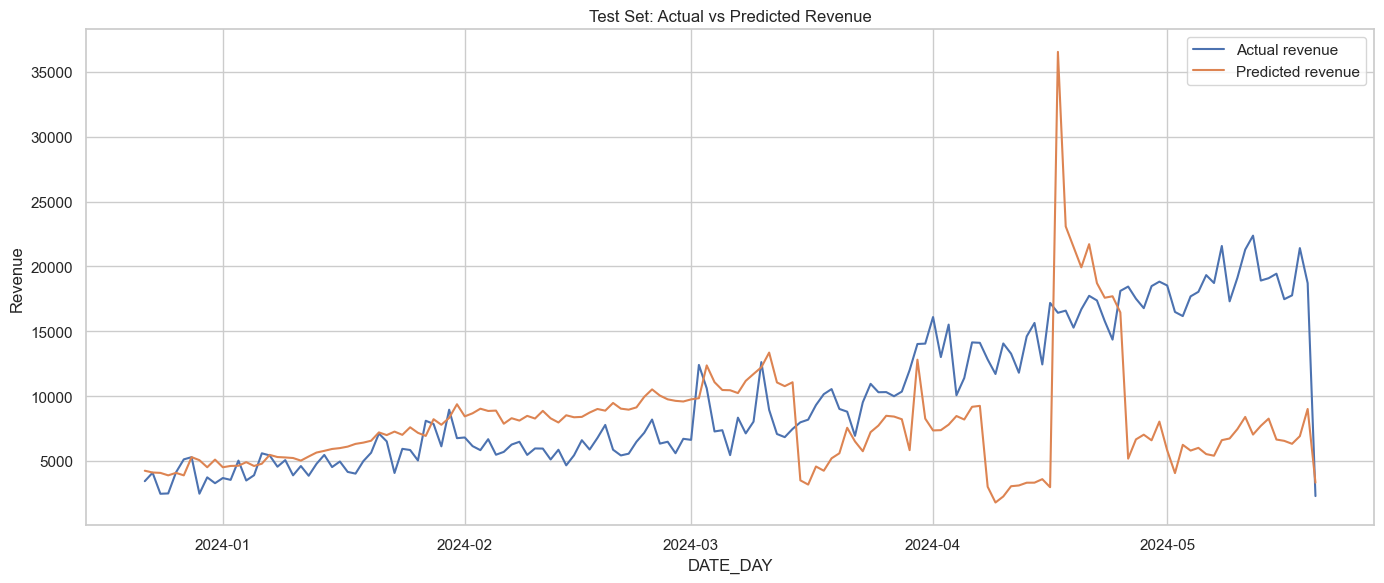

In [12]:
# Explain: Create or format a visualization.
plt.figure(figsize=(14, 6))
# Explain: Create or format a visualization.
sns.lineplot(data=test_predictions, x=DATE_COLUMN, y="revenue", label="Actual revenue")
# Explain: Create or format a visualization.
sns.lineplot(data=test_predictions, x=DATE_COLUMN, y="predicted_revenue", label="Predicted revenue")
# Explain: Create or format a visualization.
plt.title("Test Set: Actual vs Predicted Revenue")
# Explain: Create or format a visualization.
plt.ylabel("Revenue")
# Explain: Create or format a visualization.
plt.tight_layout()

### Figure interpretation

- The model captures the broad direction of revenue over time, but the prediction line does not consistently follow the magnitude of actual movements.
- There are clear periods of over-prediction and under-prediction (including a sharp predicted spike), which indicates unstable fit on parts of the holdout window.
- This visual is consistent with the test metrics section (high error and weak explanatory power), so forecast accuracy should be treated as moderate-to-low for point prediction.
- Practical implication: use this model primarily for directional scenario comparison (which channel has relatively better incremental response), not as an exact daily revenue predictor.


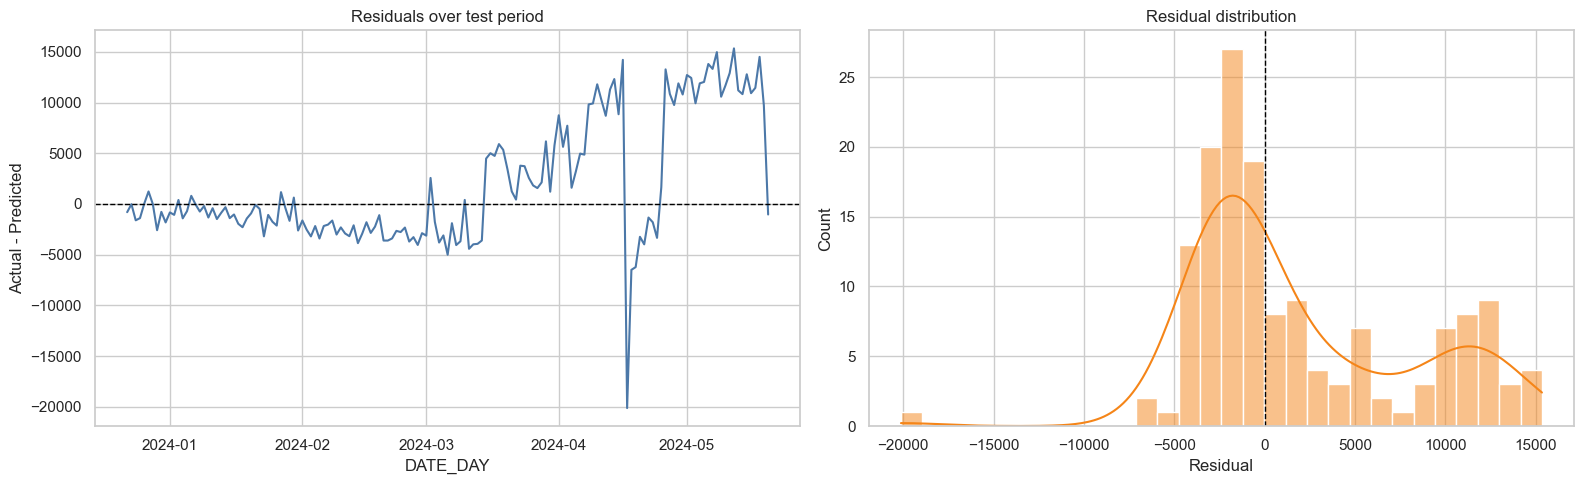

In [13]:
# Explain: Create or update residual errors for diagnostics.
test_predictions["residual"] = test_predictions["revenue"] - test_predictions["predicted_revenue"]
# Explain: Create absolute error magnitude for easier interpretation.
test_predictions["absolute_error"] = test_predictions["residual"].abs()

# Explain: Build a two-panel residual diagnostics figure.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Explain: Plot residuals over time to detect drift, bias, or structural periods.
sns.lineplot(data=test_predictions, x=DATE_COLUMN, y="residual", ax=axes[0], color="#4c78a8")
# Explain: Draw a zero-error reference line.
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
# Explain: Title and axis labels for the residual-over-time panel.
axes[0].set_title("Residuals over test period")
axes[0].set_ylabel("Actual - Predicted")

# Explain: Plot residual distribution to inspect spread and skewness.
sns.histplot(test_predictions["residual"], bins=30, kde=True, ax=axes[1], color="#f58518")
# Explain: Draw a zero-error reference line on the distribution panel.
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
# Explain: Title and axis labels for residual distribution.
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")

# Explain: Adjust plot layout for readability.
plt.tight_layout()

### Figure interpretation

- Residuals are not randomly centered around zero across time: the test period shows clear negative and positive stretches, indicating temporal bias rather than purely random noise.
- The series includes very large outliers (roughly around -20k and +15k), so the model occasionally makes substantial misses on specific dates.
- The histogram is wide and right-skewed/bimodal, which suggests error variance is high and forecast uncertainty is not uniform across the period.
- Practical implication: channel recommendations should be treated as directional; confidence in exact day-level revenue prediction is limited for this run.


## 9. Historical channel percentages for the selected series

In [14]:
# Explain: Create or update a variable used later.
historical_spend = series_df[spend_cols].sum().rename("historical_spend")
# Explain: Create or update a variable used later.
historical_share = (historical_spend / historical_spend.sum()).rename("historical_spend_share")

# Explain: Create or update a variable used later.
channel_percentages = pd.concat([historical_spend, historical_share], axis=1).reset_index()
# Explain: Create or update a variable used later.
channel_percentages.columns = ["channel", "historical_spend", "historical_spend_share"]
# Explain: Create or update a variable used later.
channel_percentages["historical_spend_share_pct"] = 100 * channel_percentages["historical_spend_share"]
# Explain: Create or update a variable used later.
channel_percentages = channel_percentages.sort_values("historical_spend_share_pct", ascending=False).reset_index(drop=True)
# Explain: Execute this step in the workflow.
channel_percentages

,channel,historical_spend,historical_spend_share,historical_spend_share_pct
0,META_FACEBOOK_SPEND,"1,212,130.8332",0.3629,36.2910
1,META_INSTAGRAM_SPEND,"896,231.9023",0.2683,26.8331
2,GOOGLE_PMAX_SPEND,"801,963.9917",0.2401,24.0107
3,GOOGLE_PAID_SEARCH_SPEND,"334,392.4920",0.1001,10.0117
4,GOOGLE_SHOPPING_SPEND,"85,391.9560",0.0256,2.5566
5,TIKTOK_SPEND,"8,798.9900",0.0026,0.2634
6,GOOGLE_DISPLAY_SPEND,600.8800,0.0002,0.0180
7,GOOGLE_VIDEO_SPEND,300.3700,0.0001,0.0090
8,META_OTHER_SPEND,216.9122,0.0001,0.0065


### Table interpretation

- The table shows each channel's historical budget share percentage.
- Larger percentages indicate channels already receiving most spend.
- This becomes the baseline for later uplift-vs-allocation comparison.


## 10. Simulate future channel investment and rank channels

In [15]:
# Explain: Create or update a variable used later.
simulation_model_name = best_ml_model_name
# Explain: Apply a condition to control execution.
if simulation_model_name == "bootstrapped_ridge":
    # Explain: Create or update a variable used later.
    simulation_model = fit_bootstrapped_ridge(X_train_valid, y_train_valid, n_bootstrap=50, alpha=1.0, random_state=42)
# Explain: Run the fallback branch when prior conditions fail.
else:
    # Explain: Create or update a variable used later.
    simulation_model = models[simulation_model_name]
    # Explain: Execute this step in the workflow.
    simulation_model.fit(X_train_valid, y_train_valid)

# Explain: Create or update a variable used later.
scenario_base = feature_df.iloc[[-1]].copy()
# Explain: Apply a condition to control execution.
if simulation_model_name == "bootstrapped_ridge":
    # Explain: Create or update a variable used later.
    baseline_prediction = np.expm1(predict_bootstrapped_ridge(simulation_model, scenario_base[feature_cols]))[0]
# Explain: Run the fallback branch when prior conditions fail.
else:
    # Explain: Create or update a variable used later.
    baseline_prediction = np.expm1(simulation_model.predict(scenario_base[feature_cols]))[0]

# Explain: Create or update a variable used later.
scenario_results = []
# Explain: Create or update a variable used later.
investment_pct_increase = 0.10

# Explain: Start a loop over a sequence.
for channel in spend_cols:
    # Explain: Create or update a variable used later.
    scenario = scenario_base.copy()
    # Explain: Create or update a variable used later.
    current_spend = scenario[channel].iloc[0]
    # Explain: Create or update a variable used later.
    new_spend = current_spend * (1 + investment_pct_increase)
    # Explain: Create or update a variable used later.
    extra_spend = new_spend - current_spend

    # Explain: Create or update a variable used later.
    scenario[channel] = new_spend
    # Explain: Create or update a variable used later.
    scenario["total_paid_spend"] = scenario[spend_cols].sum(axis=1)
    # Explain: Start a loop over a sequence.
    for spend_feature in spend_cols:
        # Explain: Create or update a variable used later.
        scenario[f"log_{spend_feature}"] = np.log1p(scenario[spend_feature])
        # Explain: Create or update a variable used later.
        scenario[f"{spend_feature}_share"] = scenario[spend_feature] / scenario["total_paid_spend"].replace(0, np.nan)

    # Explain: Apply a condition to control execution.
    if simulation_model_name == "bootstrapped_ridge":
        # Explain: Create or update a variable used later.
        predicted_revenue = np.expm1(predict_bootstrapped_ridge(simulation_model, scenario[feature_cols]))[0]
    # Explain: Run the fallback branch when prior conditions fail.
    else:
        # Explain: Create or update a variable used later.
        predicted_revenue = np.expm1(simulation_model.predict(scenario[feature_cols]))[0]
    # Explain: Create or update a variable used later.
    revenue_uplift = predicted_revenue - baseline_prediction
    # Explain: Create or update a variable used later.
    uplift_per_extra_spend = revenue_uplift / extra_spend if extra_spend > 0 else np.nan

    # Explain: Execute this step in the workflow.
    scenario_results.append(
        # Explain: Execute this step in the workflow.
        {
            # Explain: Execute this step in the workflow.
            "channel": channel,
            # Explain: Execute this step in the workflow.
            "current_spend": current_spend,
            # Explain: Execute this step in the workflow.
            "extra_spend_if_increased_10pct": extra_spend,
            # Explain: Execute this step in the workflow.
            "baseline_predicted_revenue": baseline_prediction,
            # Explain: Execute this step in the workflow.
            "scenario_predicted_revenue": predicted_revenue,
            # Explain: Execute this step in the workflow.
            "predicted_revenue_uplift": revenue_uplift,
            # Explain: Execute this step in the workflow.
            "uplift_pct_vs_baseline": 100 * revenue_uplift / baseline_prediction if baseline_prediction > 0 else np.nan,
            # Explain: Execute this step in the workflow.
            "uplift_per_extra_spend": uplift_per_extra_spend,
        # Explain: Execute this step in the workflow.
        }
    # Explain: Execute this step in the workflow.
    )

# Explain: Create or update a variable used later.
scenario_results_df = pd.DataFrame(scenario_results)
# Explain: Create or update a variable used later.
scenario_results_df = scenario_results_df.merge(channel_percentages[["channel", "historical_spend_share_pct"]], on="channel", how="left")
# Explain: Create or update a variable used later.
scenario_results_df = scenario_results_df.sort_values("uplift_per_extra_spend", ascending=False).reset_index(drop=True)
# Explain: Execute this step in the workflow.
scenario_results_df

,channel,current_spend,extra_spend_if_increased_10pct,baseline_predicted_revenue,scenario_predicted_revenue,predicted_revenue_uplift,uplift_pct_vs_baseline,uplift_per_extra_spend,historical_spend_share_pct
0,META_OTHER_SPEND,0.0254,0.0025,"3,326.9132","3,327.1305",0.2173,0.0065,85.4744,0.0065
1,META_FACEBOOK_SPEND,126.8421,12.6842,"3,326.9132","3,432.7946",105.8813,3.1826,8.3475,36.2910
2,META_INSTAGRAM_SPEND,32.1045,3.2105,"3,326.9132","3,345.2217",18.3085,0.5503,5.7028,26.8331
3,GOOGLE_PMAX_SPEND,190.1612,19.0161,"3,326.9132","3,382.0802",55.1670,1.6582,2.9011,24.0107
4,GOOGLE_PAID_SEARCH_SPEND,5.8100,0.5810,"3,326.9132","3,319.7999",-7.1133,-0.2138,-12.2432,10.0117
5,TIKTOK_SPEND,10.9200,1.0920,"3,326.9132","3,293.0372",-33.8760,-1.0182,-31.0220,0.2634
6,GOOGLE_SHOPPING_SPEND,0.0000,0.0000,"3,326.9132","3,326.9132",0.0000,0.0000,NaN,2.5566
7,GOOGLE_DISPLAY_SPEND,0.0000,0.0000,"3,326.9132","3,326.9132",0.0000,0.0000,NaN,0.0180
8,GOOGLE_VIDEO_SPEND,0.0000,0.0000,"3,326.9132","3,326.9132",0.0000,0.0000,NaN,0.0090


### Table interpretation

- This scenario table is the core decision output: predicted revenue response by channel for +10% spend.
- `uplift_per_extra_spend` is the key ranking metric for capital efficiency.
- Channels near the top are the strongest candidates for incremental investment tests.


Interpretation:
- `historical_spend_share_pct` tells you what percentage of the existing budget each channel has received historically.
- `predicted_revenue_uplift` tells you the modeled revenue lift from increasing only that channel by 10%.
- `uplift_per_extra_spend` is the most useful directional ranking metric here. A higher value means more predicted incremental revenue for each extra unit of spend.
- The top-ranked channel is the best candidate for additional investment under this model.

In [16]:
# Explain: Create or update a variable used later.
top_recommendation = scenario_results_df.iloc[0]
# Explain: Execute this step in the workflow.
top_recommendation

channel                           META_OTHER_SPEND
current_spend                               0.0254
extra_spend_if_increased_10pct              0.0025
baseline_predicted_revenue              3,326.9132
scenario_predicted_revenue              3,327.1305
predicted_revenue_uplift                    0.2173
uplift_pct_vs_baseline                      0.0065
uplift_per_extra_spend                     85.4744
historical_spend_share_pct                  0.0065
Name: 0, dtype: object

C:\Users\cindy\AppData\Local\Temp\ipykernel_16512\1884816126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=scenario_results_df, y="channel", x="uplift_per_extra_spend", palette="viridis")


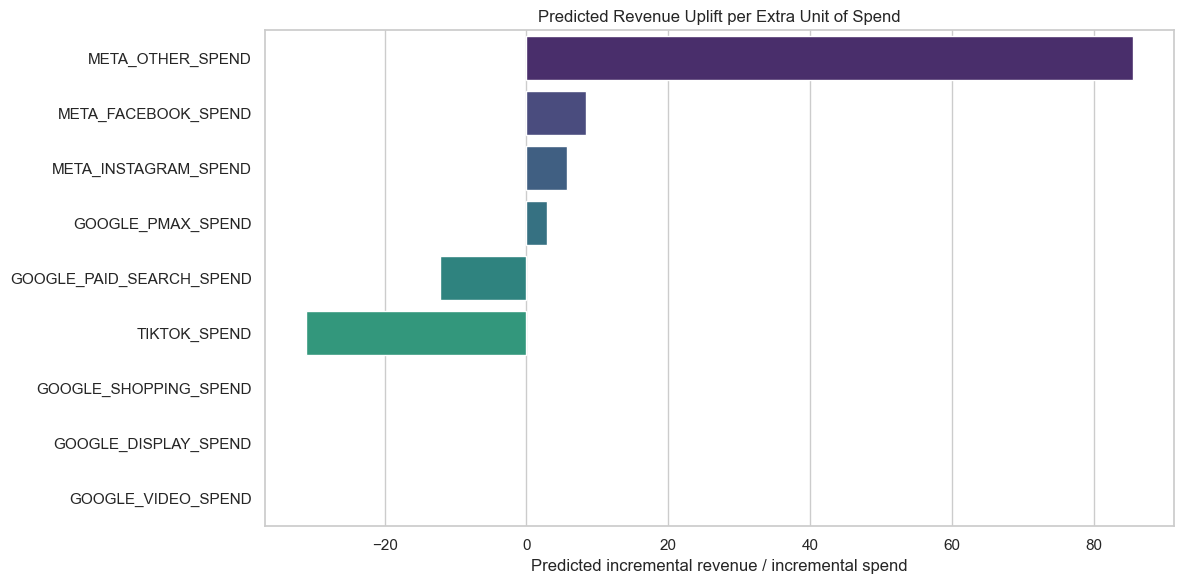

In [17]:
# Explain: Create or format a visualization.
plt.figure(figsize=(12, 6))
# Explain: Create or format a visualization.
sns.barplot(data=scenario_results_df, y="channel", x="uplift_per_extra_spend", palette="viridis")
# Explain: Create or format a visualization.
plt.title("Predicted Revenue Uplift per Extra Unit of Spend")
# Explain: Create or format a visualization.
plt.xlabel("Predicted incremental revenue / incremental spend")
# Explain: Create or format a visualization.
plt.ylabel("")
# Explain: Create or format a visualization.
plt.tight_layout()

### Figure interpretation

- This chart ranks channels by modeled marginal efficiency (`uplift_per_extra_spend`), so it shows where an extra unit of budget is predicted to work best.
- In this run, `META_OTHER_SPEND` is the clear outlier at about `85.4744`, far above `META_FACEBOOK_SPEND` (`8.3475`), `META_INSTAGRAM_SPEND` (`5.7028`), and `GOOGLE_PMAX_SPEND` (`2.9011`).
- `GOOGLE_PAID_SEARCH_SPEND` (`-12.2432`) and `TIKTOK_SPEND` (`-31.0220`) are negative, which indicates additional spend is predicted to reduce (or not improve) revenue in this local simulation.
- `GOOGLE_SHOPPING_SPEND`, `GOOGLE_DISPLAY_SPEND`, and `GOOGLE_VIDEO_SPEND` are around zero in this setup, so they are not priority channels for extra budget under the current model.
- Decision implication: prioritise channels with strong positive bars first, and treat negative-bar channels as hold/review candidates unless business constraints require always-on spend.


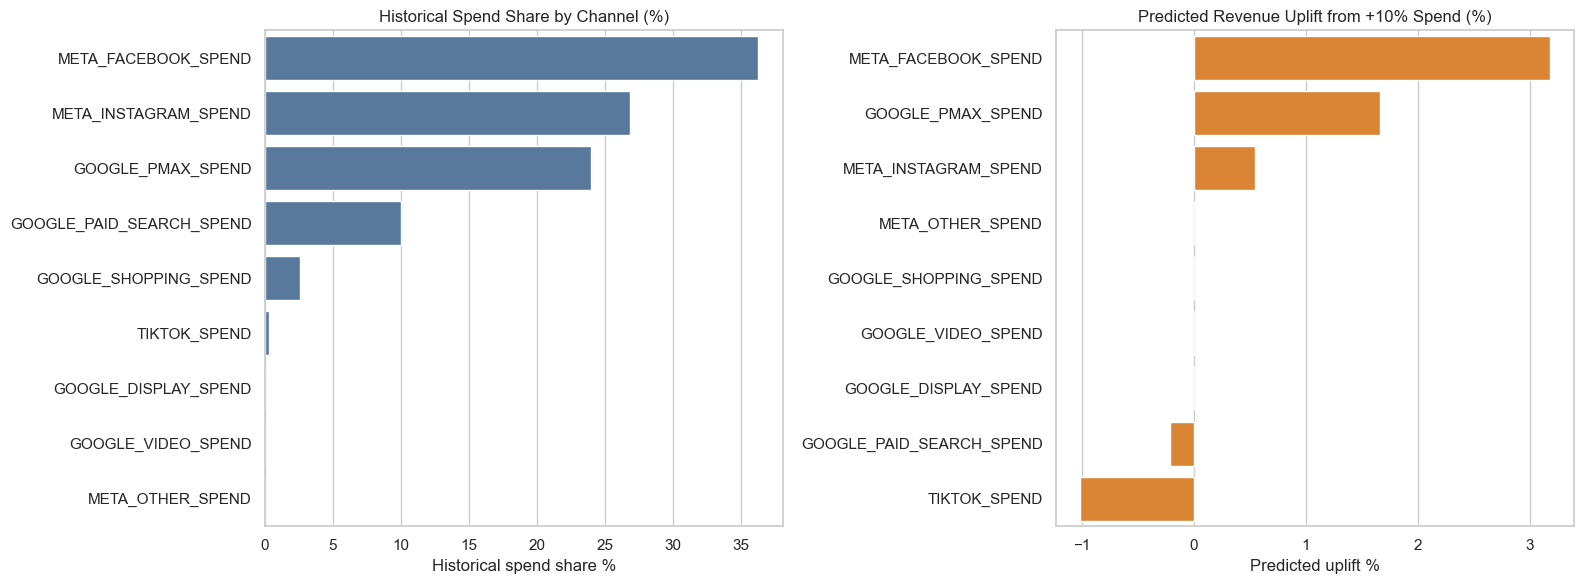

In [18]:
# Explain: Create or update a variable used later.
comparison_plot_df = scenario_results_df[["channel", "historical_spend_share_pct", "uplift_pct_vs_baseline"]].copy()
# Explain: Create or update a variable used later.
comparison_plot_df = comparison_plot_df.sort_values("historical_spend_share_pct", ascending=False)

# Explain: Create or update a variable used later.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Explain: Create or format a visualization.
sns.barplot(data=comparison_plot_df, y="channel", x="historical_spend_share_pct", ax=axes[0], color="#4c78a8")
# Explain: Execute this step in the workflow.
axes[0].set_title("Historical Spend Share by Channel (%)")
# Explain: Execute this step in the workflow.
axes[0].set_xlabel("Historical spend share %")
# Explain: Execute this step in the workflow.
axes[0].set_ylabel("")

# Explain: Create or format a visualization.
sns.barplot(data=comparison_plot_df.sort_values("uplift_pct_vs_baseline", ascending=False), y="channel", x="uplift_pct_vs_baseline", ax=axes[1], color="#f58518")
# Explain: Execute this step in the workflow.
axes[1].set_title("Predicted Revenue Uplift from +10% Spend (%)")
# Explain: Execute this step in the workflow.
axes[1].set_xlabel("Predicted uplift %")
# Explain: Execute this step in the workflow.
axes[1].set_ylabel("")

# Explain: Create or format a visualization.
plt.tight_layout()

### Figure interpretation

- Current spend is concentrated in `META_FACEBOOK_SPEND`, `META_INSTAGRAM_SPEND`, and `GOOGLE_PMAX_SPEND` (left panel).
- The uplift simulation (right panel) indicates the strongest positive incremental response from `META_FACEBOOK_SPEND`, followed by `GOOGLE_PMAX_SPEND`, then `META_INSTAGRAM_SPEND`.
- `GOOGLE_PAID_SEARCH_SPEND` and `TIKTOK_SPEND` show negative uplift in this +10% test, which suggests extra short-term spend in these channels is less efficient under the current model setup.
- `META_OTHER_SPEND` appears near zero uplift in this specific chart; treat this as model-specific and validate with additional tests before large budget shifts.
- Business implication: incremental budget should be prioritised to the highest positive-uplift channels first, while negative-uplift channels should be reviewed and potentially reduced or held flat.


## 11. Business answer

In [19]:
# Explain: Create or update a variable used later.
business_answer = pd.DataFrame(
    # Explain: Execute this step in the workflow.
    {
        # Explain: Execute this step in the workflow.
        "selected_series_id": [selected_series_id],
        # Explain: Execute this step in the workflow.
        "currency_code": [selected_meta["currency_code"]],
        # Explain: Execute this step in the workflow.
        "territory_name": [selected_meta["territory_name"]],
        # Explain: Execute this step in the workflow.
        "best_validation_model": [best_model_name],
        # Explain: Execute this step in the workflow.
        "simulation_model": [best_ml_model_name],
        # Explain: Execute this step in the workflow.
        "recommended_channel_to_increase": [top_recommendation["channel"]],
        # Explain: Execute this step in the workflow.
        "historical_spend_share_pct": [top_recommendation["historical_spend_share_pct"]],
        # Explain: Execute this step in the workflow.
        "predicted_revenue_uplift_from_10pct_increase": [top_recommendation["predicted_revenue_uplift"]],
        # Explain: Execute this step in the workflow.
        "uplift_per_extra_spend": [top_recommendation["uplift_per_extra_spend"]],
    # Explain: Execute this step in the workflow.
    }
# Explain: Execute this step in the workflow.
)
# Explain: Execute this step in the workflow.
business_answer

,selected_series_id,currency_code,territory_name,best_validation_model,simulation_model,recommended_channel_to_increase,historical_spend_share_pct,predicted_revenue_uplift_from_10pct_increase,uplift_per_extra_spend
0,f7493de0a760f84888105af70245bed3,USD,All Territories,bootstrapped_ridge,bootstrapped_ridge,META_OTHER_SPEND,0.0065,0.2173,85.4744


### Table interpretation

- This summary gives the final business recommendation in one row.
- It identifies the selected model, recommended channel, and expected uplift signal.
- This is the most report-ready output for the coursework conclusion section.


## 12. Budget allocation recommendation by channel (%)

This section converts model-estimated channel efficiency into a recommended **future budget percentage split**.

Method used:
- Use `uplift_per_extra_spend` from scenario results as the channel efficiency score.
- Replace negative scores with zero (do not allocate extra budget to negative-efficiency channels).
- Normalise positive scores to 100% to get recommended allocation percentages.


In [20]:
# Explain: Select key fields needed for budget-allocation logic.
allocation_df = scenario_results_df[["channel", "historical_spend_share_pct", "uplift_per_extra_spend", "predicted_revenue_uplift"]].copy()
# Explain: Replace missing uplift estimates with 0 so every channel gets a numeric allocation output.
allocation_df["uplift_per_extra_spend"] = allocation_df["uplift_per_extra_spend"].fillna(0)
# Explain: Keep only non-negative efficiency for allocation scoring.
allocation_df["positive_efficiency"] = allocation_df["uplift_per_extra_spend"].clip(lower=0)

# Explain: Define total future budget for allocation (edit this value for your scenario).
total_future_budget = 100000.0
# Explain: Calculate total efficiency score across channels.
total_positive_efficiency = allocation_df["positive_efficiency"].sum()

# Explain: Apply fallback if all efficiencies are non-positive.
if total_positive_efficiency <= 0:
    # Explain: Fall back to historical budget share when no positive signal exists.
    allocation_df["recommended_share_pct"] = allocation_df["historical_spend_share_pct"].fillna(0)
else:
    # Explain: Convert efficiency scores to recommended budget percentages.
    allocation_df["recommended_share_pct"] = 100 * allocation_df["positive_efficiency"] / total_positive_efficiency

# Explain: Force any remaining missing percentages to 0 for a complete channel table.
allocation_df["recommended_share_pct"] = allocation_df["recommended_share_pct"].fillna(0)

# Explain: Convert recommended percentages to budget amounts.
allocation_df["recommended_budget_amount"] = total_future_budget * allocation_df["recommended_share_pct"] / 100
# Explain: Sort channels by recommended percentage, highest first.
allocation_df = allocation_df.sort_values("recommended_share_pct", ascending=False).reset_index(drop=True)
# Explain: Display the full recommended allocation table.
allocation_df


,channel,historical_spend_share_pct,uplift_per_extra_spend,predicted_revenue_uplift,positive_efficiency,recommended_share_pct,recommended_budget_amount
0,META_OTHER_SPEND,0.0065,85.4744,0.2173,85.4744,83.4501,"83,450.1384"
1,META_FACEBOOK_SPEND,36.2910,8.3475,105.8813,8.3475,8.1498,"8,149.7963"
2,META_INSTAGRAM_SPEND,26.8331,5.7028,18.3085,5.7028,5.5677,"5,567.7058"
3,GOOGLE_PMAX_SPEND,24.0107,2.9011,55.1670,2.9011,2.8324,"2,832.3596"
4,GOOGLE_PAID_SEARCH_SPEND,10.0117,-12.2432,-7.1133,0.0000,0.0000,0.0000
5,TIKTOK_SPEND,0.2634,-31.0220,-33.8760,0.0000,0.0000,0.0000
6,GOOGLE_SHOPPING_SPEND,2.5566,0.0000,0.0000,0.0000,0.0000,0.0000
7,GOOGLE_DISPLAY_SPEND,0.0180,0.0000,0.0000,0.0000,0.0000,0.0000
8,GOOGLE_VIDEO_SPEND,0.0090,0.0000,0.0000,0.0000,0.0000,0.0000


### Table interpretation

- `recommended_share_pct` is the model-driven percentage split for future budget allocation.
- `recommended_budget_amount` converts that percentage into currency amount for the chosen total budget.
- Compare `historical_spend_share_pct` vs `recommended_share_pct` to see which channels are under- or over-allocated.


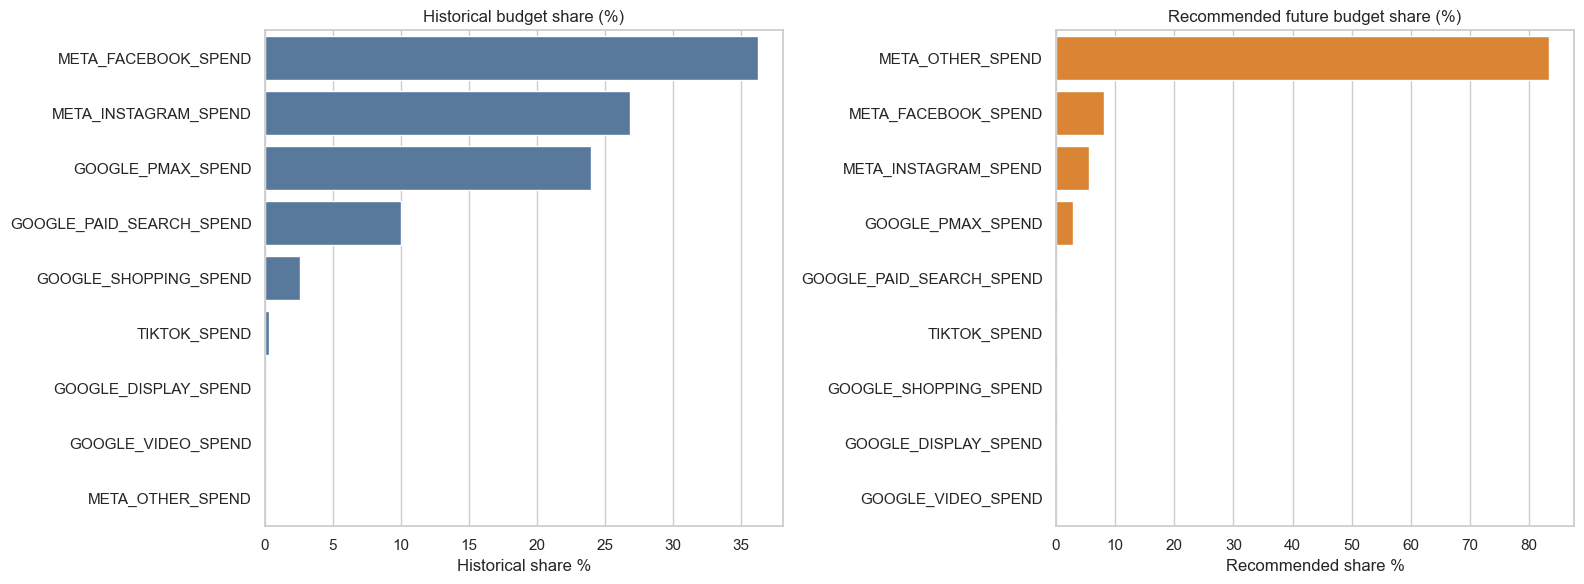

In [21]:
# Explain: Create a two-panel comparison chart for historical vs recommended percentages.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Explain: Sort channels by historical share for the left panel.
left_df = allocation_df.sort_values("historical_spend_share_pct", ascending=False)
# Explain: Plot historical budget shares.
sns.barplot(data=left_df, y="channel", x="historical_spend_share_pct", ax=axes[0], color="#4c78a8")
# Explain: Add title and axis label for historical panel.
axes[0].set_title("Historical budget share (%)")
axes[0].set_xlabel("Historical share %")
axes[0].set_ylabel("")

# Explain: Sort channels by recommended share for the right panel.
right_df = allocation_df.sort_values("recommended_share_pct", ascending=False)
# Explain: Plot recommended future budget shares.
sns.barplot(data=right_df, y="channel", x="recommended_share_pct", ax=axes[1], color="#f58518")
# Explain: Add title and axis label for recommended panel.
axes[1].set_title("Recommended future budget share (%)")
axes[1].set_xlabel("Recommended share %")
axes[1].set_ylabel("")

# Explain: Adjust layout for readability.
plt.tight_layout()


### Figure interpretation

- Historical allocation is concentrated in `META_FACEBOOK_SPEND` (36.2910%), `META_INSTAGRAM_SPEND` (26.8331%), and `GOOGLE_PMAX_SPEND` (24.0107%).
- The model-based incremental allocation shifts strongly toward `META_OTHER_SPEND` (83.4501%), while `META_FACEBOOK_SPEND` (8.1498%), `META_INSTAGRAM_SPEND` (5.5677%), and `GOOGLE_PMAX_SPEND` (2.8324%) remain secondary.
- `GOOGLE_PAID_SEARCH_SPEND`, `TIKTOK_SPEND`, `GOOGLE_SHOPPING_SPEND`, `GOOGLE_DISPLAY_SPEND`, and `GOOGLE_VIDEO_SPEND` are assigned 0% in this run because their estimated incremental efficiency is non-positive (or effectively zero after preprocessing).
- Practical reading: this chart is a **reallocation signal for additional budget**, not evidence that historical spend on other channels had no value.


In [22]:
# Explain: Capture the top recommended channel from allocation output.
top_budget_channel = allocation_df.iloc[0]
# Explain: Build a compact conclusion table for report-ready output.
budget_conclusion = pd.DataFrame({
    # Explain: Store selected modelling context fields.
    "selected_series_id": [selected_series_id],
    # Explain: Store currency context.
    "currency_code": [selected_meta["currency_code"]],
    # Explain: Save best model used for simulation.
    "simulation_model": [best_ml_model_name],
    # Explain: Store highest-priority channel for future budget.
    "top_recommended_budget_channel": [top_budget_channel["channel"]],
    # Explain: Store recommended future budget percentage for top channel.
    "top_recommended_share_pct": [top_budget_channel["recommended_share_pct"]],
    # Explain: Store recommended budget amount for top channel.
    "top_recommended_budget_amount": [top_budget_channel["recommended_budget_amount"]],
})
# Explain: Display bottom-line allocation conclusion output.
budget_conclusion


,selected_series_id,currency_code,simulation_model,top_recommended_budget_channel,top_recommended_share_pct,top_recommended_budget_amount
0,f7493de0a760f84888105af70245bed3,USD,bootstrapped_ridge,META_OTHER_SPEND,83.4501,"83,450.1384"


## Budget allocation conclusion

The table above gives a model-driven answer to **how much percentage of money to invest in each channel** under the selected budget scenario.

Interpretation rule:
- Use `recommended_share_pct` as the future budget split by channel.
- Use `recommended_budget_amount` for actionable spend planning.
- Prioritise the top channel(s) first, then validate with controlled tests before large reallocation.


## Final conclusion

Based on the current notebook run, the model recommends increasing investment in **`META_OTHER_SPEND`** first to maximise future revenue.

Why this channel is selected:
- It has the highest **`uplift_per_extra_spend`** in the scenario test (`85.4744`), meaning the strongest predicted revenue gain per additional unit of spend.
- In the +10% spend simulation, it produces a positive **predicted revenue uplift** (`+0.2173`) on the selected time-series setup.
- Its current historical spend share is very low (`0.0065%`), so the model sees it as potentially under-invested relative to predicted response.

Important caveat:
- This is a model-based directional recommendation from one selected series; it should be validated with controlled tests or broader MMM analysis before large budget reallocation.

Recommended additional-budget percentage split (current run):
- `META_OTHER_SPEND`: `83.4501%`
- `META_FACEBOOK_SPEND`: `8.1498%`
- `META_INSTAGRAM_SPEND`: `5.5677%`
- `GOOGLE_PMAX_SPEND`: `2.8324%`
- `GOOGLE_PAID_SEARCH_SPEND`: `0.0000%`
- `TIKTOK_SPEND`: `0.0000%`
- `GOOGLE_SHOPPING_SPEND`: `0.0000%`
- `GOOGLE_DISPLAY_SPEND`: `0.0000%`
- `GOOGLE_VIDEO_SPEND`: `0.0000%`
